In [1]:
from matplotlib import pyplot
import numpy as np

In [2]:
import h5py

In [3]:
import os
import sys
from os.path import join

In [4]:
f = h5py.File(join(os.environ['DATADIR'], '300wlp.h5'), 'r')

In [5]:
f.keys()

<KeysViewHDF5 ['coords', 'files', 'images', 'pt3d_68', 'quats', 'rois', 'shapeparams']>

In [6]:
#the_slice = slice(400)
the_slice = slice(None)

In [7]:
allparams = np.array(f['shapeparams'][the_slice])
params = allparams[:,-10:]
coord = np.array(f['coords'][the_slice])
#sequence_starts = np.array(f['sequence_starts'])
#fitlosses = np.array(f['fitloss'])
N = params.shape[0]
N

61225

Find samples with large shape parameter magnitude.
-----------------------------------------------------------------------------
Those are the grimmaces.

In [8]:
if 1:
    indices = []
    for i in range(10):
        j = np.argsort(np.abs(params[:,i]))[-9*5:]
        indices.append(j)
    indices = np.concatenate(indices)
    indices = np.unique(indices)
    indices = indices[np.argsort(np.sum(np.abs(params[:,:10]), axis=1)[indices])]
else:
    indices = np.argsort(np.abs(fitlosses))[-N//500:]

In [9]:
indices[-9*5:]

array([18202, 17917, 44315, 41107, 22558, 40399,  9742,  9950, 20073,
       12215, 55430, 54679, 54425, 38134, 19645,  4943, 18996, 10456,
       23189, 25449, 25699,   448,  2886, 13961, 29616,  8793, 38085,
        9163, 17626, 46388, 51208, 20919, 20285, 26906, 41553, 60891,
       48477,  7330, 23179, 24997,  8981, 56562,  8831, 40787, 37913])

## Check correlations between size and parameters
Its about the face size and the face shape paramters

In [10]:
vcombined = np.concatenate([coord[:,2:], allparams], axis=1)
vcombined -= np.average(vcombined, axis=0)
cov = np.cov(vcombined.T)

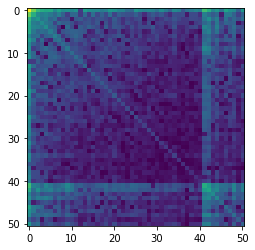

In [11]:
# Graphical display of correlations.
# Given a row, we can see across the columns how strongly those parameters vary with the parameter of the row.
pyplot.imshow(np.log(1.e-5+np.abs(cov)))

<BarContainer object of 51 artists>

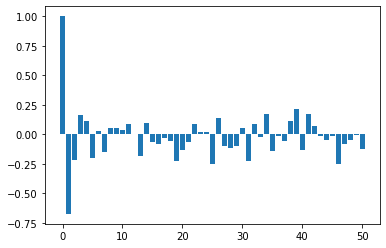

In [12]:
# Plot correlations of the size variable with the other parameters.
# Now these are the proper correlation coefficients.
corr = cov[0]/np.sqrt(cov[0,0]*np.diag(cov))
pyplot.bar(np.arange(cov.shape[0]), height=corr)

In [13]:
# 25% Correlation (on aflw2k) is maybe not so nice. There might be ambiguity between the shape and the size variable.
# That is, size goes up and shape parameters change to compensate yielding the same overall face.
# The first shape vector makes the yaw predominantely wider and larger but also a bit the distance between the eyes.
# So from that side it makes sense that there is some ambiguity and mostly those two variables are anti-correlated.
# In other words the base-face vector lies in the vector space spanned by the shape vectors.
# Could make it hard for the neuralnet to learn. Idk ...

In [14]:
# On 300wlp it is 75%
# On my ytfaces variant it is only 20%. Guess it was a good idea to fit with the fixed base shape first.